In [1]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={"figure.figsize":(16, 9)}) 

# Extract the current figsize to determine height and aspect for lmplot
global_fig_width, global_fig_height = plt.rcParams['figure.figsize']
global_aspect_ratio = global_fig_width / global_fig_height

In [2]:
# Directory containing the JSON files
json_folder = '../json_reports'

# List to hold the data
data = []

# Iterate over all JSON files in the directory
for filename in os.listdir(json_folder):
    if filename.endswith('.json'):
        filepath = os.path.join(json_folder, filename)
        
        # Read the JSON file
        with open(filepath, 'r', encoding='utf-8') as file:
            json_data = json.load(file)
            
            # Flatten the JSON data into a single dictionary
            flattened_data = {key: value.get('value') for key, value in json_data.items()}
            
            # Add the filename to the data
            flattened_data['filename'] = filename
            
            # Add the record to the data list
            data.append(flattened_data)

# Create a DataFrame from the data list
df = pd.DataFrame(data)

In [3]:
df

,num_estimates,num_results,num_runs_mean,num_runs_median,signed_average_error_of_individual_forecast_ie_runner_was_late_minutes,average_error_of_individual_prediction_minutes,median_error_of_individual_prediction_minutes,ratio_of_error_to_final_time,individual_interval_prediction_is_wrong,individual_faster_than_interval_prediction,...,average_error_of_relay_prediction_minutes,median_relay_prediction_error_minutes,relay_interval_prediction_wrong,runner_faster_than_relay_time_prediction,runner_slower_than_post_interval_prediction,filename,average_individual_prediction_crps,average_individual_prediction_nll,average_relay_prediction_crps,average_relay_prediction_nll
0,13587.0,13825.0,5.564574,4.0,3.830020,15.083615,10.047662,0.119542,0.037295,0.003484,...,34.519956,19.586230,0.050281,0.013382,0.036899,20250402_040004_post_race_analysis_ju_fy_2019....,NaN,NaN,NaN,NaN
1,6732.0,6888.0,4.330099,3.0,-1.069569,8.871087,6.706693,0.115224,0.010766,0.001365,...,15.524736,10.000106,0.028961,0.005914,0.023048,20250525_063459_post_race_analysis_ve_fy_2019....,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,2.052500,13.793923,8.827973,0.110638,0.041650,0.007760,...,30.513930,17.475940,0.050519,0.020429,0.030089,20230525_190013_post_race_analysis_ju_fy_2019....,NaN,NaN,NaN,NaN
3,11305.0,11578.0,6.385473,4.0,12.396391,15.690749,10.660467,0.115625,0.060924,0.001606,...,42.067606,26.784371,0.159724,0.000756,0.158969,20250601_090403_post_race_analysis_ju_fy_2024....,NaN,NaN,NaN,NaN
4,6324.0,6500.0,4.690376,3.0,-0.728092,8.468968,6.299311,0.116391,0.029002,0.015230,...,16.232991,11.413057,0.084251,0.061082,0.023169,20260327_154819_post_race_analysis_ve_fy_2018....,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,6762.0,8694.0,6.541162,5.0,5.105886,16.512365,10.800706,0.123237,0.057593,0.011415,...,39.722458,24.035653,0.104635,0.024905,0.079730,20250330_071610_post_race_analysis_ju_fy_2021....,NaN,NaN,NaN,NaN
8807,NaN,NaN,NaN,NaN,3.070339,12.626362,8.009240,0.099455,0.023802,0.002681,...,27.368623,15.846610,0.029326,0.006255,0.023071,20230526_053439_post_race_analysis_ju_fy_2018....,NaN,NaN,NaN,NaN
8808,5736.0,5892.0,5.568215,4.0,17.454178,18.409654,13.803805,0.165547,0.085673,0.000180,...,42.727362,32.934506,0.249460,0.000000,0.249460,20260331_183635_post_race_analysis_ve_fy_2025....,12.926912,4.523873,31.553122,5.600675
8809,11704.0,11879.0,5.994816,4.0,16.908272,21.092293,14.604012,0.142597,0.199574,0.003980,...,69.244559,49.469326,0.416273,0.004536,0.411737,20250401_052947_post_race_analysis_ju_fy_2023....,NaN,NaN,NaN,NaN


In [4]:
#df.info()
df.tail(1).T


,8810
num_estimates,5492.0
num_results,5704.0
num_runs_mean,5.246198
num_runs_median,4.0
signed_average_error_of_individual_forecast_ie_runner_was_late_minutes,-0.064364
average_error_of_individual_prediction_minutes,11.120434
median_error_of_individual_prediction_minutes,7.825392
ratio_of_error_to_final_time,0.114552
individual_interval_prediction_is_wrong,0.036381
individual_faster_than_interval_prediction,0.014244


In [5]:
df['post_analysis_date'] = pd.to_datetime(df['post_analysis_start_time'].astype(int), unit='s')
df['race_type'] = df['race_id'].astype(str).str[:2]
#df.head(1).T
#df['post_analysis_start_time'].astype(int)

In [6]:
#sns.scatterplot(data=df, x='post_analysis_date', y='average_error_of_individual_prediction_minutes', hue='race_id', style='race_type')

In [7]:
bad_execution_timestamps = df[(df['average_error_of_individual_prediction_minutes'] > 60) | (df['execution_timestamp'] == 'unknown')]['execution_timestamp'].values


In [8]:
bad_execution_timestamp_mask = df['execution_timestamp'].isin(bad_execution_timestamps)
clean_df = df[~bad_execution_timestamp_mask].copy()
#clean_df = clean_df.query('post_analysis_date > "2023-06-18"')
#clean_df = clean_df.query('post_analysis_date > "2024-05-23"')
clean_df = clean_df.query('post_analysis_date > "2024-06-12"')
clean_df = clean_df.sort_values(by=['race_id', 'post_analysis_date'])
clean_df['execution_time'] = pd.to_datetime(
    clean_df['execution_timestamp'],
    format='%Y%m%d_%H%M%S'
)
clean_df['race_year'] = clean_df['race_id'].str.split('_fy_').str[-1].astype(int)


def get_first_and_last(group):
    return group.iloc[[0, -1]]

first_last_df = clean_df.groupby('race_id', group_keys=False).apply(get_first_and_last).reset_index(drop=True)

#first_last_df.describe()

/var/folders/hb/h9kccyz10ll607d8m8ct22t80000gn/T/ipykernel_42065/3553955508.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_last_df = clean_df.groupby('race_id', group_keys=False).apply(get_first_and_last).reset_index(drop=True)


In [9]:

last_execution_timestamps = clean_df['execution_time'].drop_duplicates().nlargest(30)

# 1) Sort just the column (descending), drop duplicates to get unique ordered list
#unique_sorted_strings = clean_df['execution_time'] \
#    .sort_values(ascending=False) \
#    .drop_duplicates()

# 2) Take the first 10 unique values
#last_execution_timestamps = unique_sorted_strings.head(10)

#print(f'{last_execution_timestamps=}')
# 3) Filter original DataFrame for those 10 unique timestamp‐strings
last_executions_df = clean_df[clean_df['execution_time'].isin(last_execution_timestamps)]
#last_executions_df['post_analysis_date'].sort_values(ascending=False)

<Axes: xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

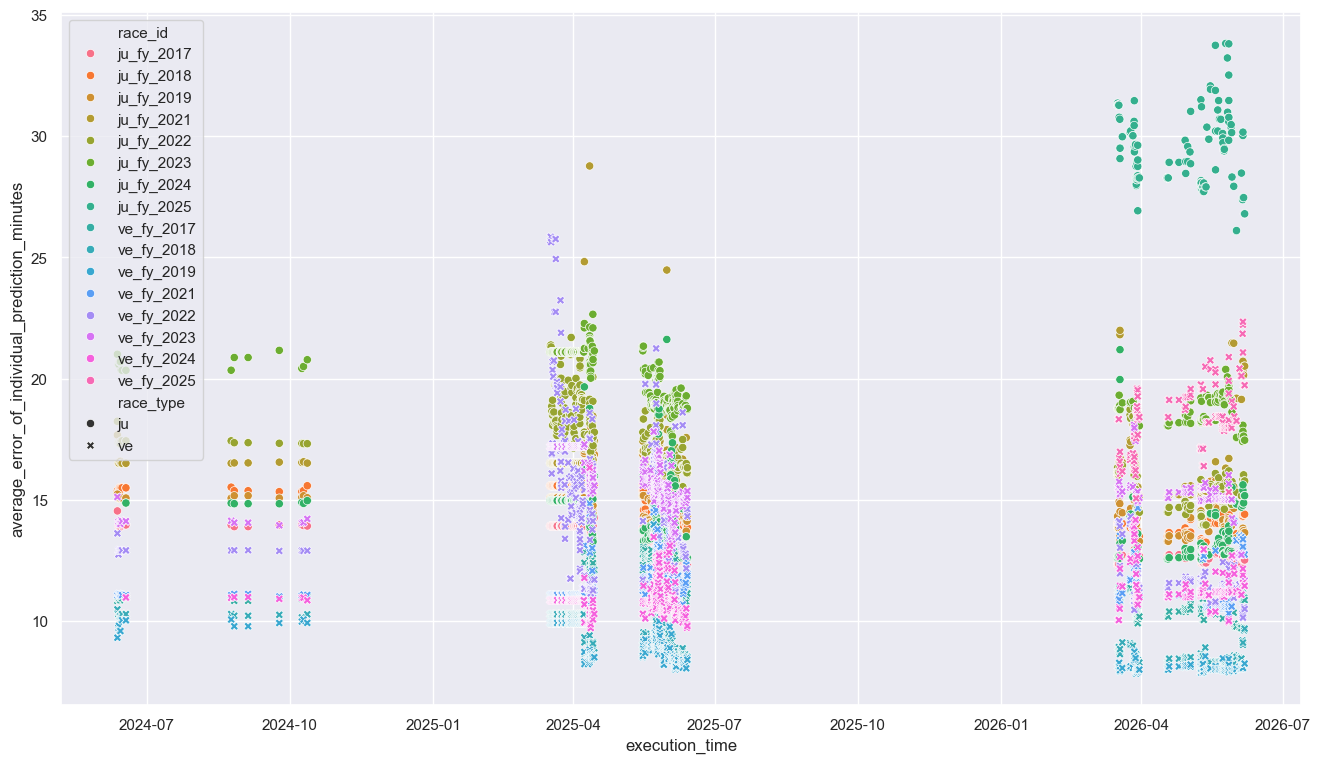

In [10]:
sns.scatterplot(data=clean_df, x='execution_time', y='average_error_of_individual_prediction_minutes', hue='race_id', style='race_type')

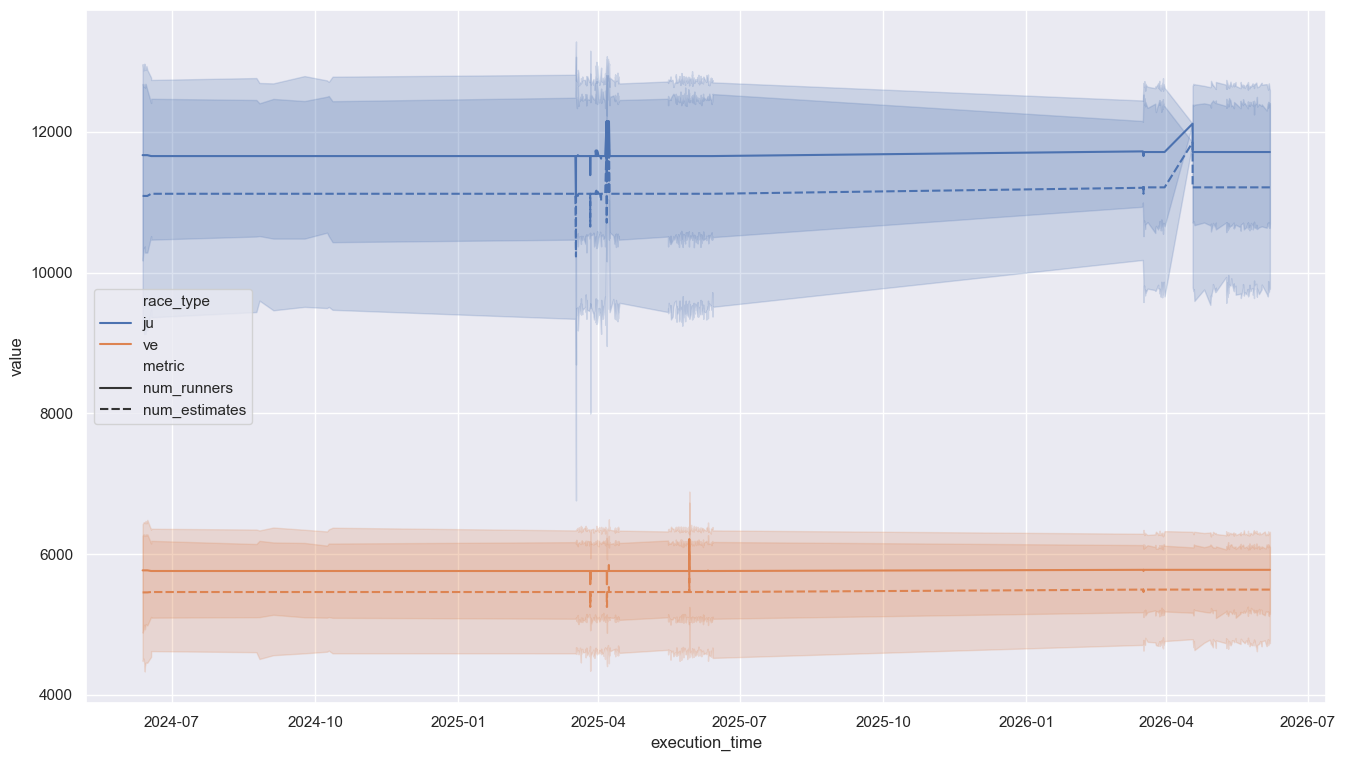

In [11]:
#ax = sns.lineplot(data=clean_df, x='execution_time', y='num_runners', hue='race_type')
#sns.lineplot(data=clean_df, x='execution_time', y='num_estimates', hue='race_type', linestyle='--', ax=ax)

melted_df = clean_df.melt(
    id_vars=['execution_time', 'race_type'],
    value_vars=['num_runners', 'num_estimates'],
    var_name='metric'
)

ax = sns.lineplot(data=melted_df, x='execution_time', y='value', hue='race_type', style='metric')

<Axes: xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

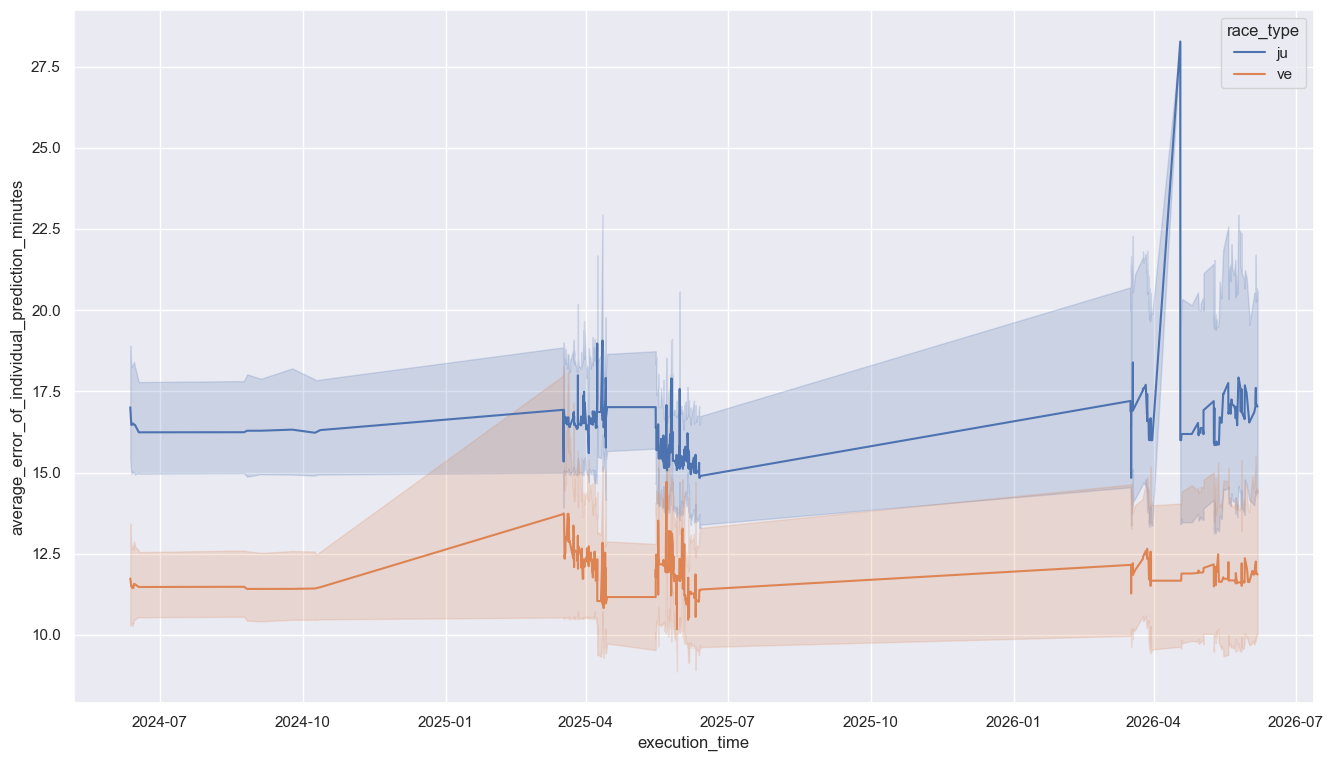

In [12]:
sns.lineplot(data=clean_df, x='execution_time', y='average_error_of_individual_prediction_minutes', hue='race_type')

<Axes: xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

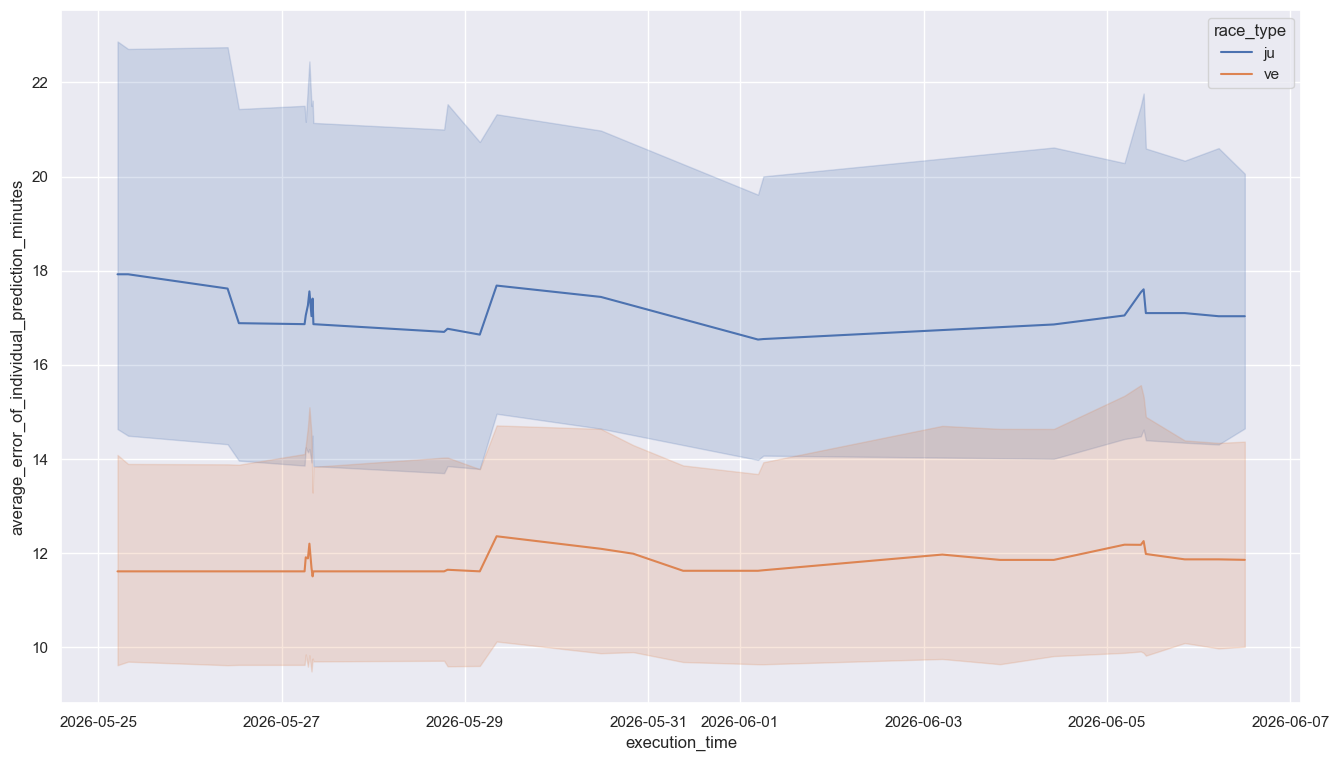

In [13]:
sns.lineplot(data=last_executions_df, x='execution_time', y='average_error_of_individual_prediction_minutes', hue='race_type')

<Axes: xlabel='execution_time', ylabel='average_individual_prediction_nll'>

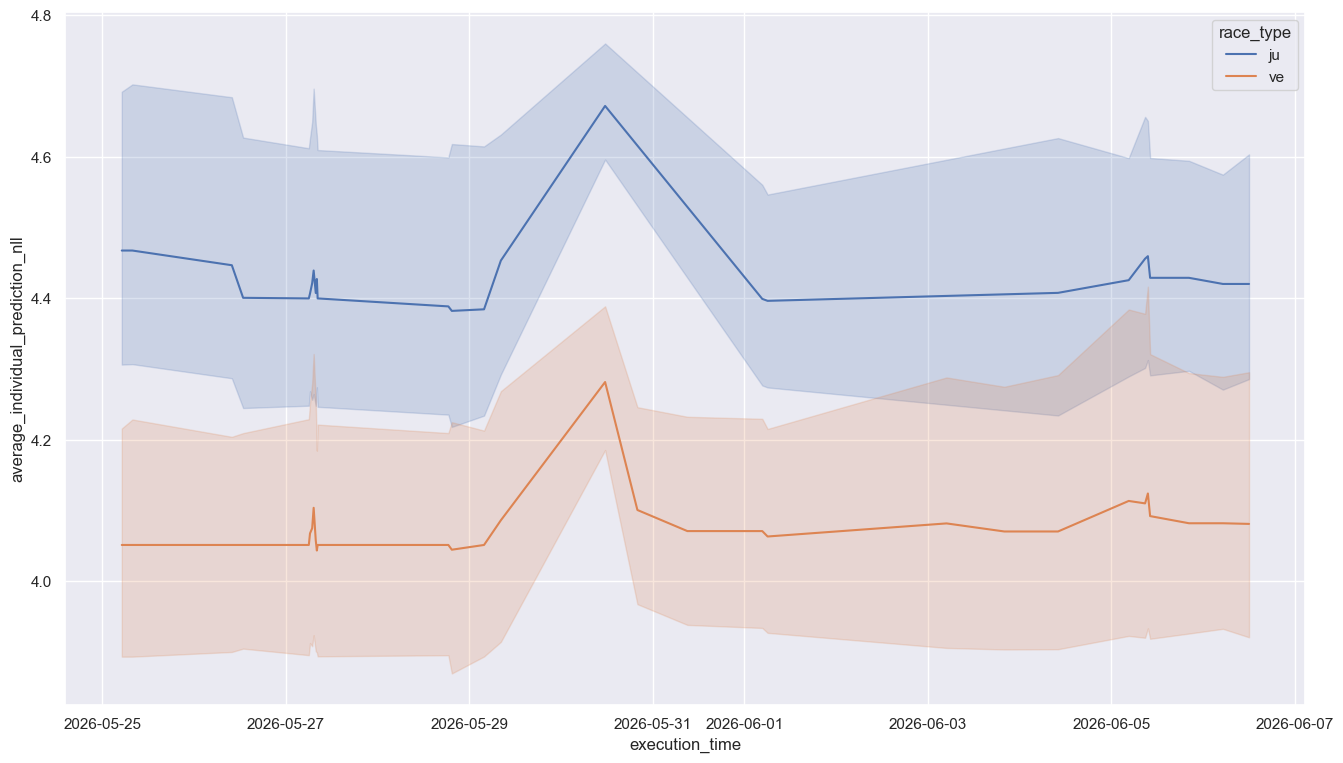

In [14]:
sns.lineplot(data=last_executions_df, x='execution_time', y='average_individual_prediction_nll', hue='race_type',)


<Axes: xlabel='execution_time', ylabel='individual_interval_prediction_is_wrong'>

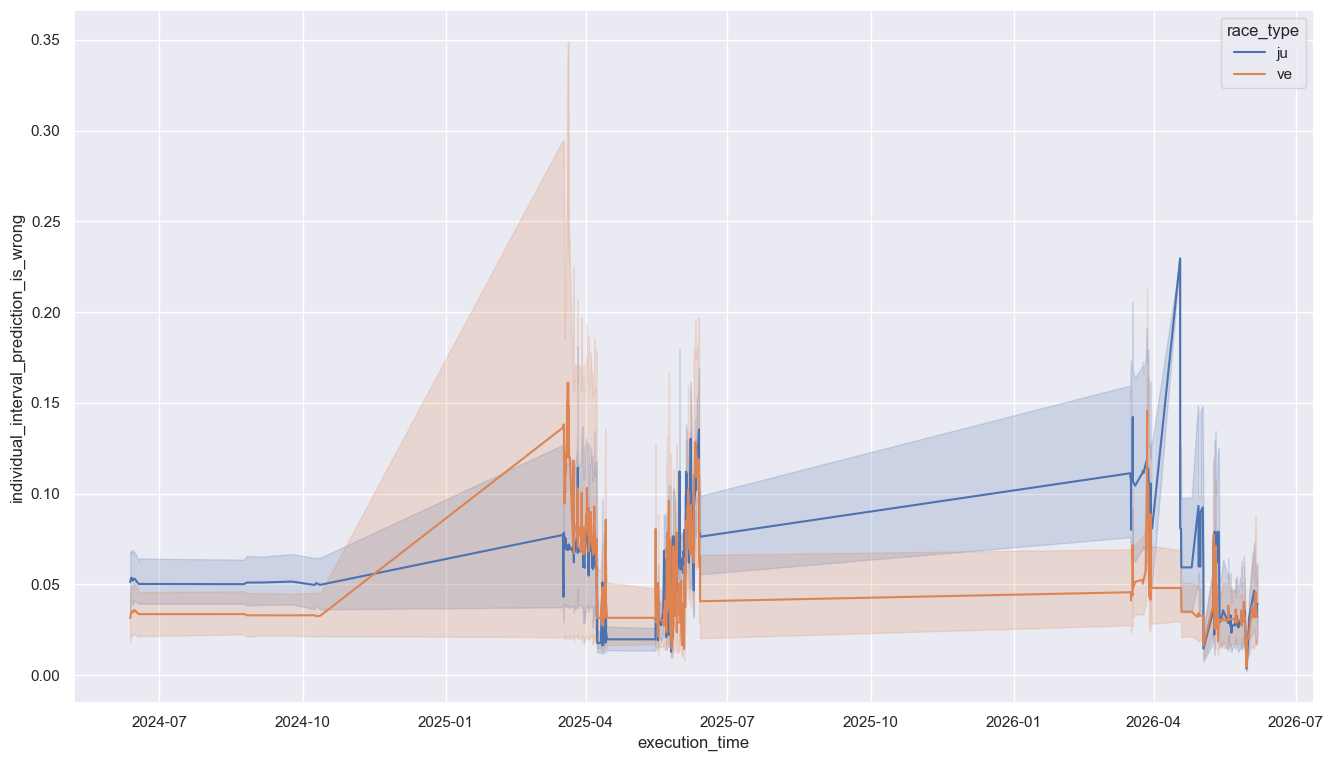

In [15]:
sns.lineplot(data=clean_df, x='execution_time', y='individual_interval_prediction_is_wrong', hue='race_type',)

<Axes: xlabel='execution_time', ylabel='individual_interval_prediction_is_wrong'>

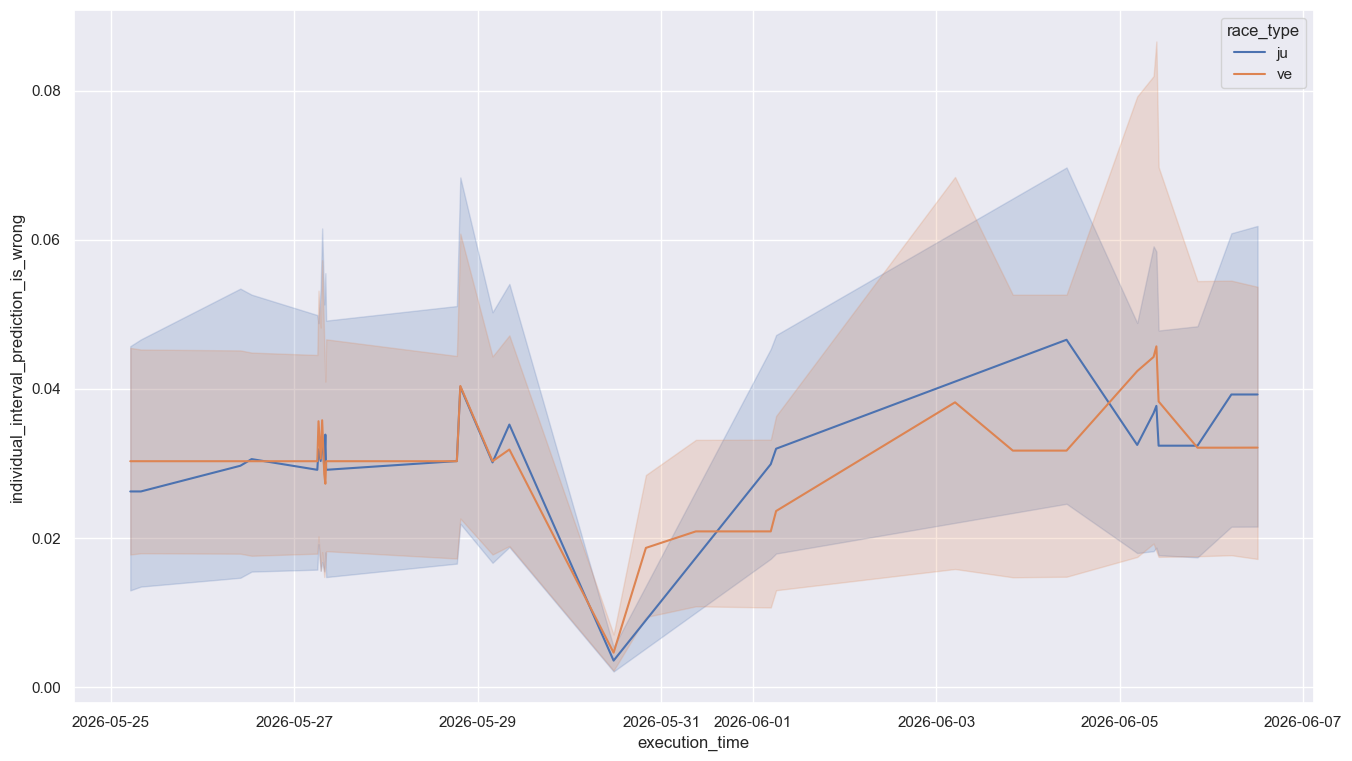

In [16]:
sns.lineplot(data=last_executions_df, x='execution_time', y='individual_interval_prediction_is_wrong', hue='race_type',)

<Axes: xlabel='execution_time', ylabel='average_size_of_an_individual_interval_minutes'>

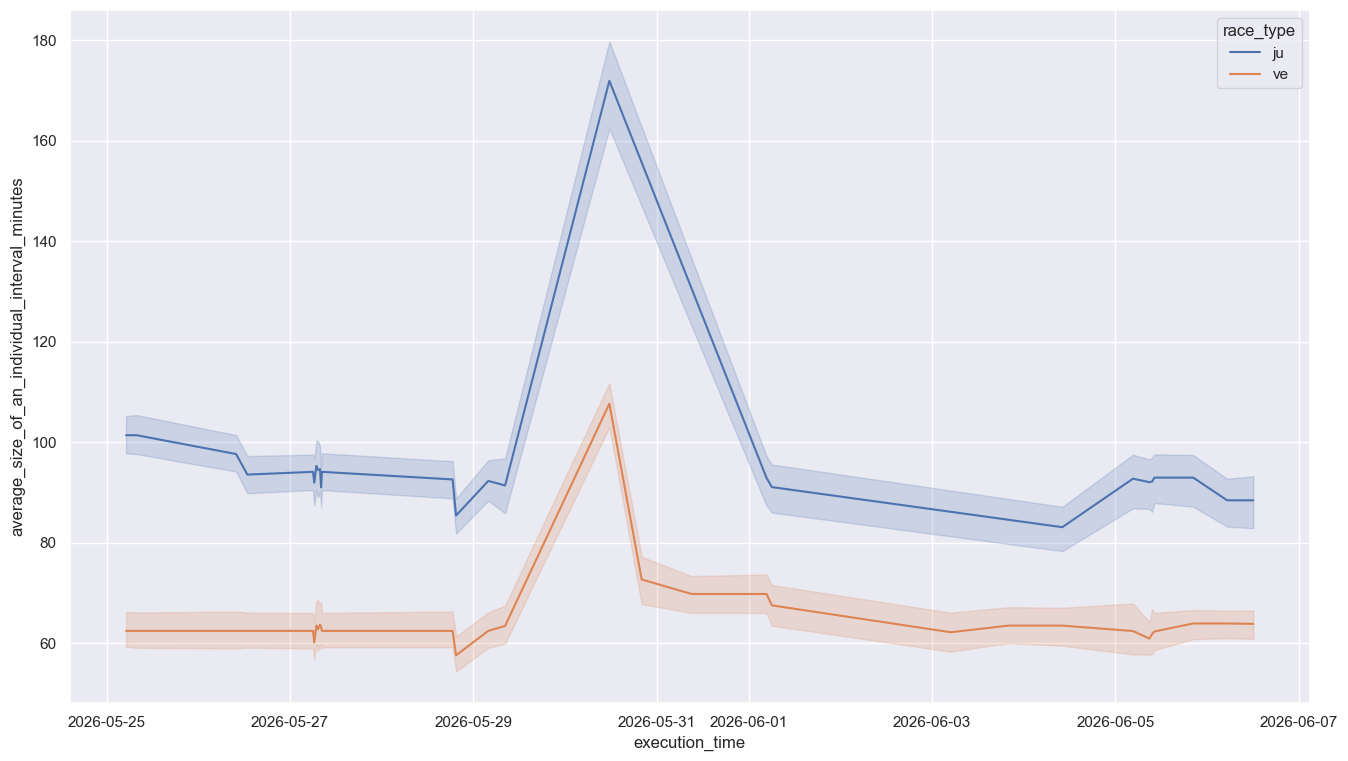

In [17]:
sns.lineplot(data=last_executions_df, x='execution_time', y='average_size_of_an_individual_interval_minutes', hue='race_type',)

In [18]:
def annotated_lineplot(df, x, y, hue, style=None, figsize=(16, 9), annotation_col=None, fontsize=7, x_margin=0.1, ax=None):
    """
    Seaborn lineplot with end-of-line annotations.

    Parameters
    ----------
    df             : DataFrame
    x, y           : column names for axes
    hue            : column used for color grouping (also annotated by default)
    style          : column used for line style (optional)
    figsize        : figure size (ignored if ax is provided)
    annotation_col : column to use for annotation text; defaults to `hue`
    fontsize       : annotation font size
    x_margin       : right-side margin to avoid clipping annotations
    ax             : existing Axes to plot on (optional)
    """
    annotation_col = annotation_col or hue

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.lineplot(data=df, x=x, y=y, hue=hue, style=style, ax=ax)

    for group_val, group_df in df.groupby(hue):
        last_row = group_df.sort_values(x).iloc[-1]
        ax.annotate(
            str(last_row[annotation_col]),
            xy=(last_row[x], last_row[y]),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=fontsize,
            va='center',
            fontweight='bold',
        )

    ax.margins(x=x_margin)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(y)
    return ax

<Axes: title={'center': 'average_error_of_individual_prediction_minutes'}, xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

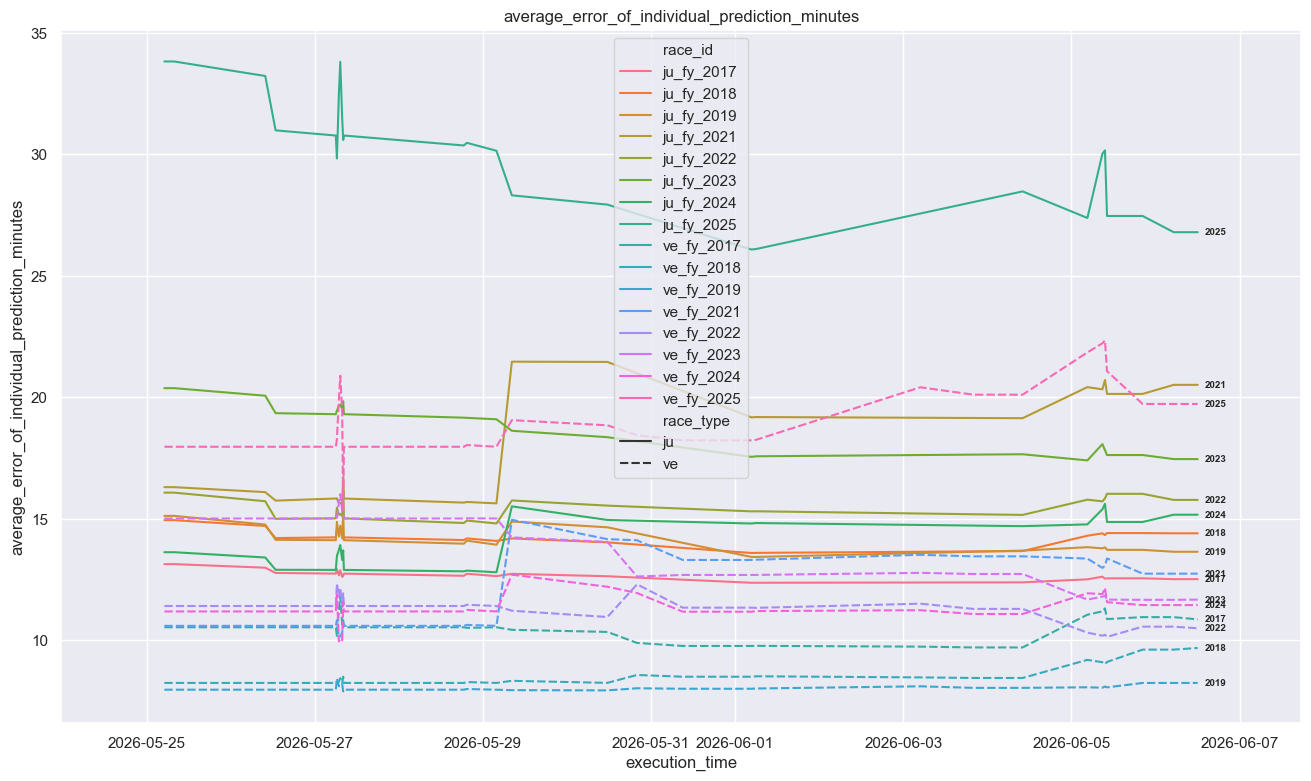

In [19]:
annotated_lineplot(
    last_executions_df,
    x='execution_time',
    y='average_error_of_individual_prediction_minutes',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

In [20]:

min_indices = (
    clean_df
    .groupby('race_type')['average_error_of_individual_prediction_minutes']
    .idxmin()
)

clean_df.loc[min_indices, [
    'race_type',
    'execution_timestamp',
    'execution_time',
    'average_error_of_individual_prediction_minutes'
]]

,race_type,execution_timestamp,execution_time,average_error_of_individual_prediction_minutes
7474,ju,20250602_182635,2025-06-02 18:26:35,12.240864
4001,ve,20260328_175752,2026-03-28 17:57:52,7.837700


<Axes: title={'center': 'num_runners'}, xlabel='execution_time', ylabel='num_runners'>

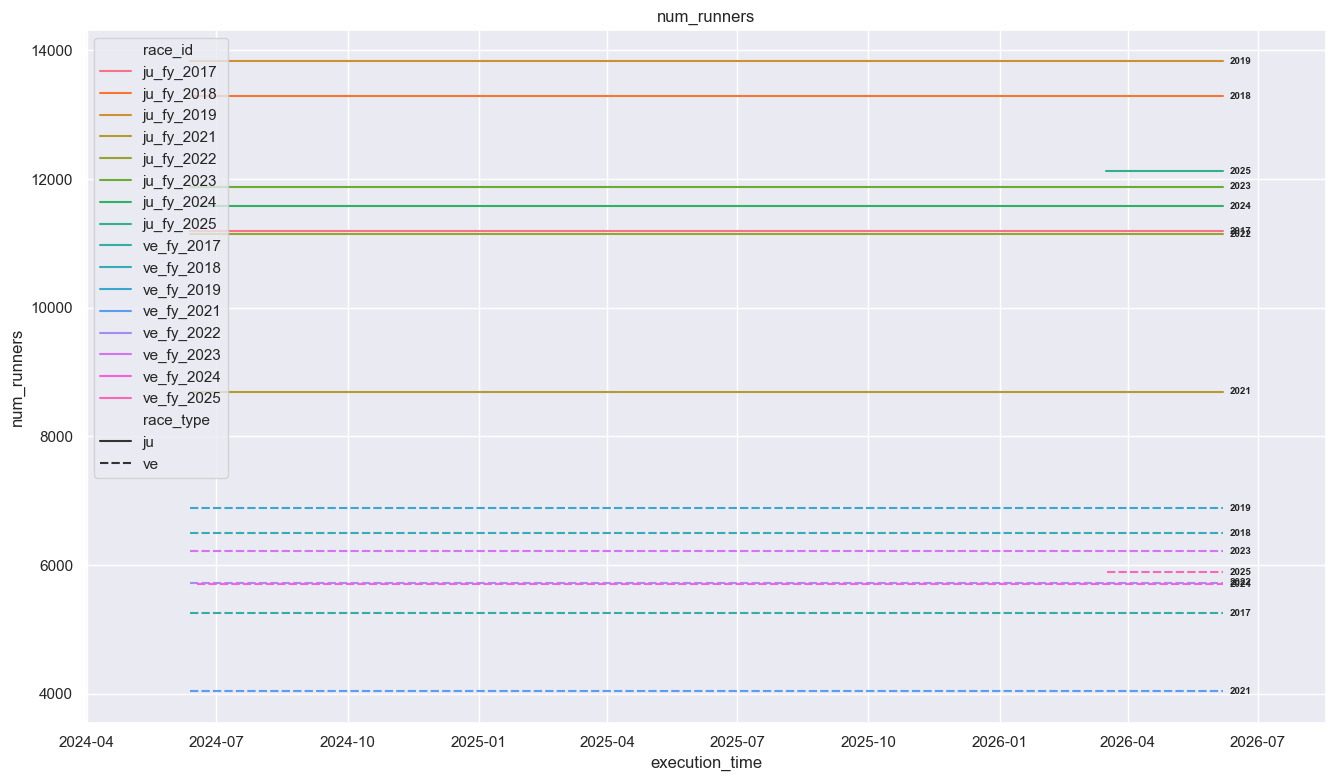

In [21]:
annotated_lineplot(
    clean_df,
    x='execution_time',
    y='num_runners',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'average_error_of_individual_prediction_minutes'}, xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

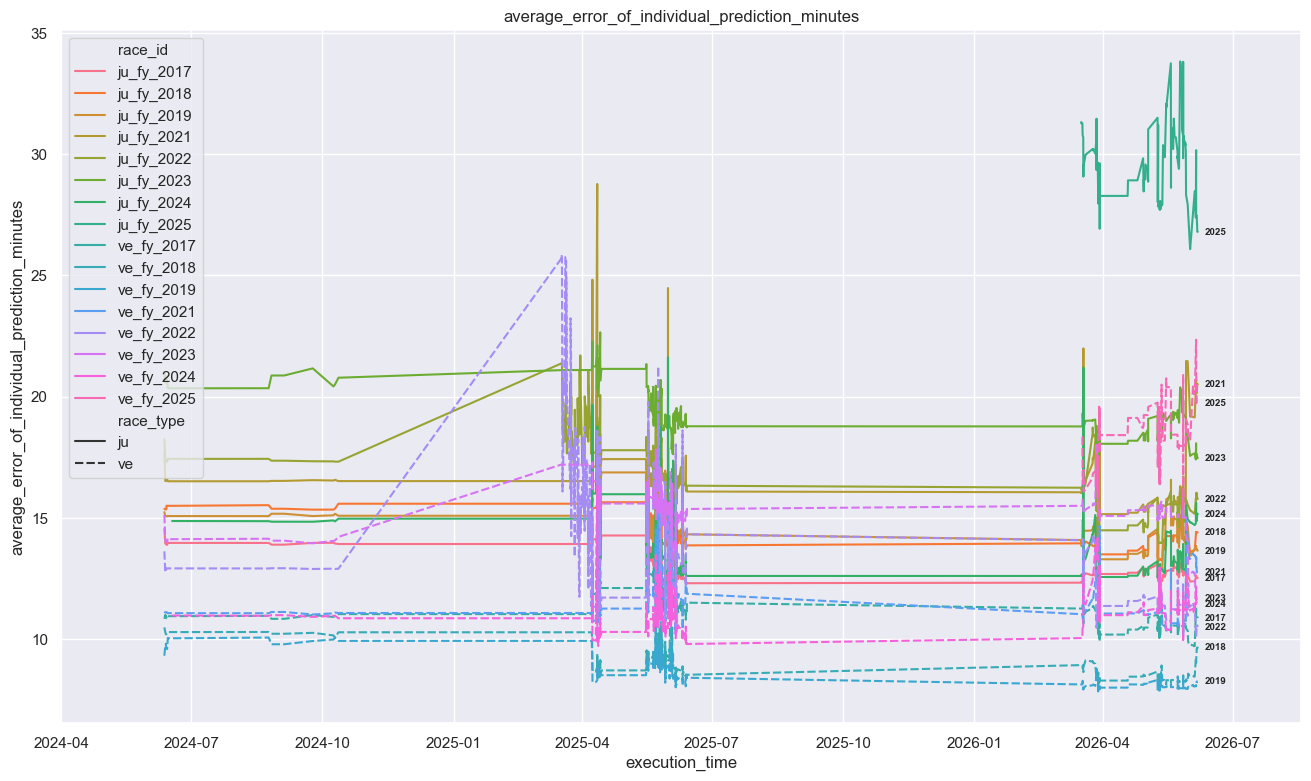

In [22]:
annotated_lineplot(
    clean_df,
    x='execution_time',
    y='average_error_of_individual_prediction_minutes',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'average_individual_prediction_crps'}, xlabel='execution_time', ylabel='average_individual_prediction_crps'>

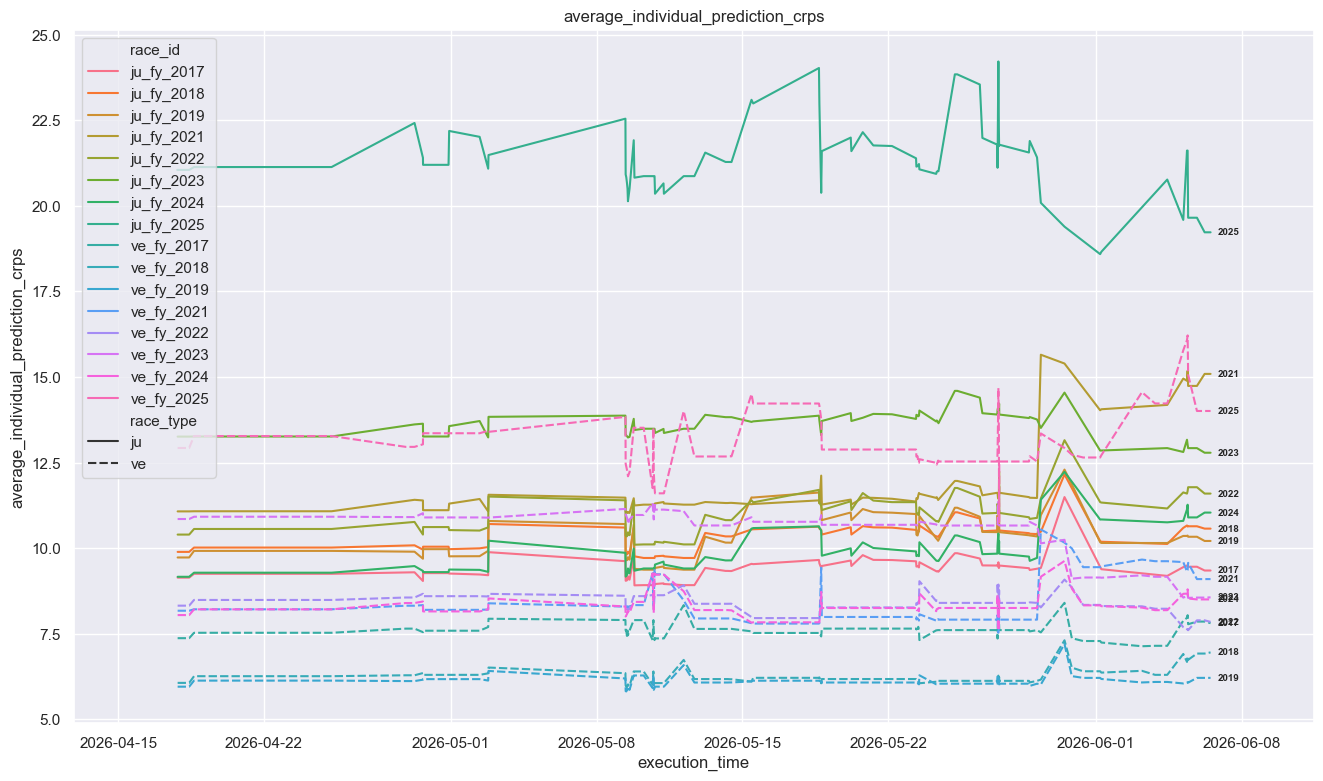

In [23]:
annotated_lineplot(
    clean_df,
    x='execution_time',
    y='average_individual_prediction_crps',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

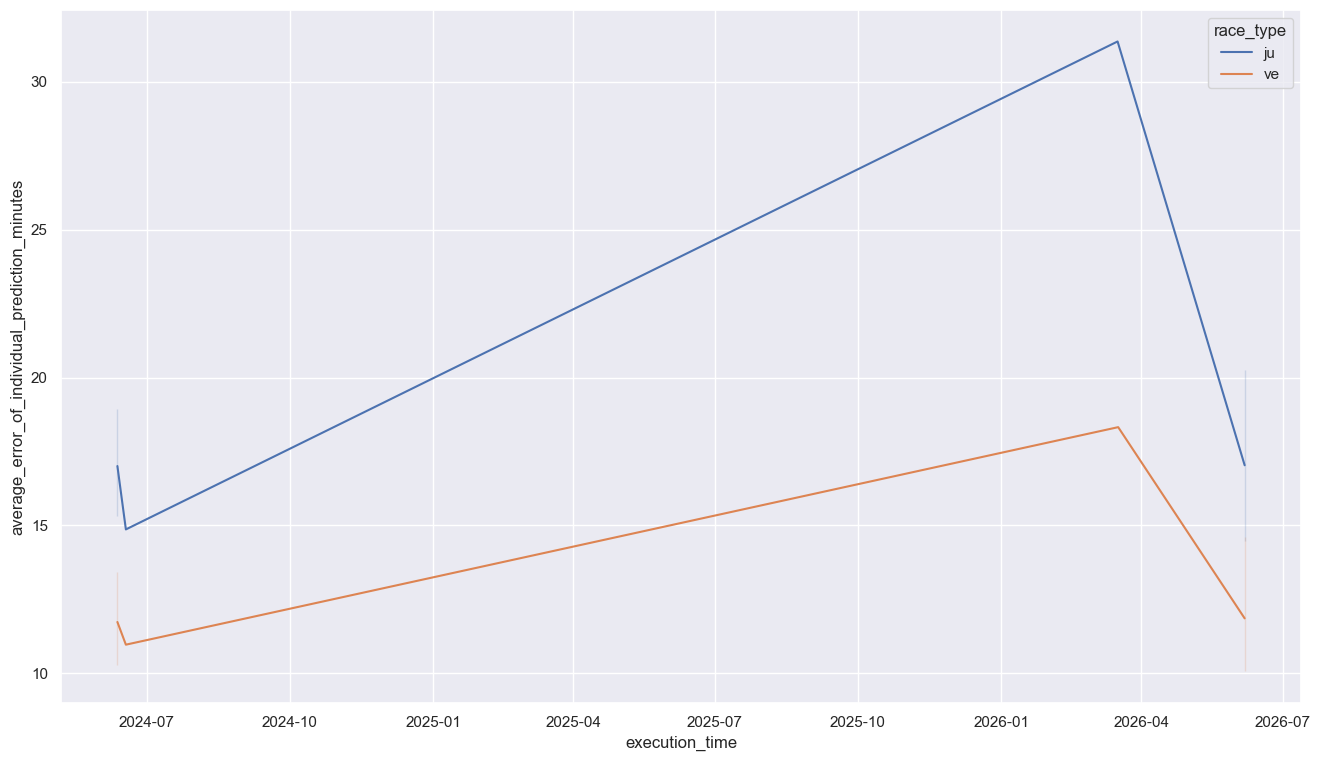

In [24]:
sns.lineplot(data=first_last_df, x='execution_time', y='average_error_of_individual_prediction_minutes', hue='race_type')

<Axes: title={'center': 'average_error_of_individual_prediction_minutes'}, xlabel='execution_time', ylabel='average_error_of_individual_prediction_minutes'>

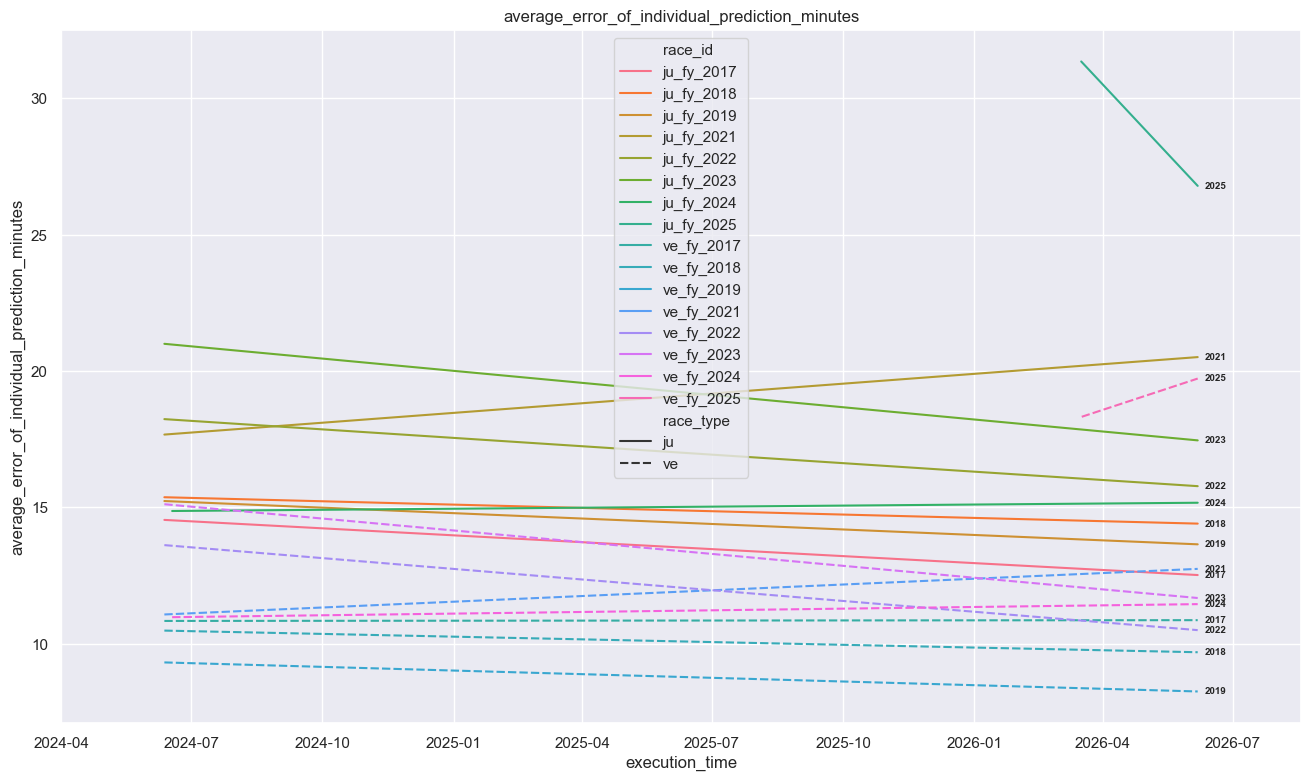

In [25]:
annotated_lineplot(
    first_last_df,
    x='execution_time',
    y='average_error_of_individual_prediction_minutes',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'individual_interval_prediction_is_wrong'}, xlabel='execution_time', ylabel='individual_interval_prediction_is_wrong'>

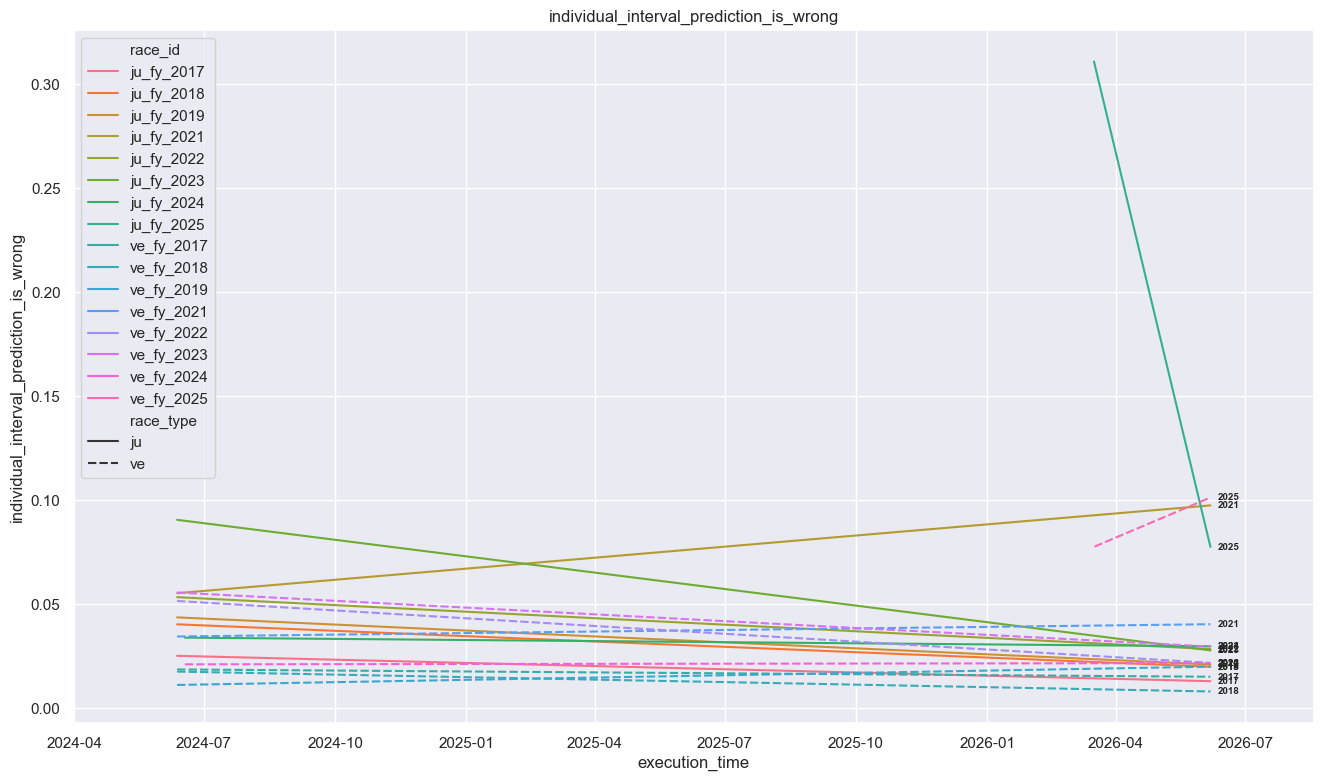

In [26]:
annotated_lineplot(
    first_last_df,
    x='execution_time',
    y='individual_interval_prediction_is_wrong',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'individual_interval_prediction_is_wrong'}, xlabel='execution_time', ylabel='individual_interval_prediction_is_wrong'>

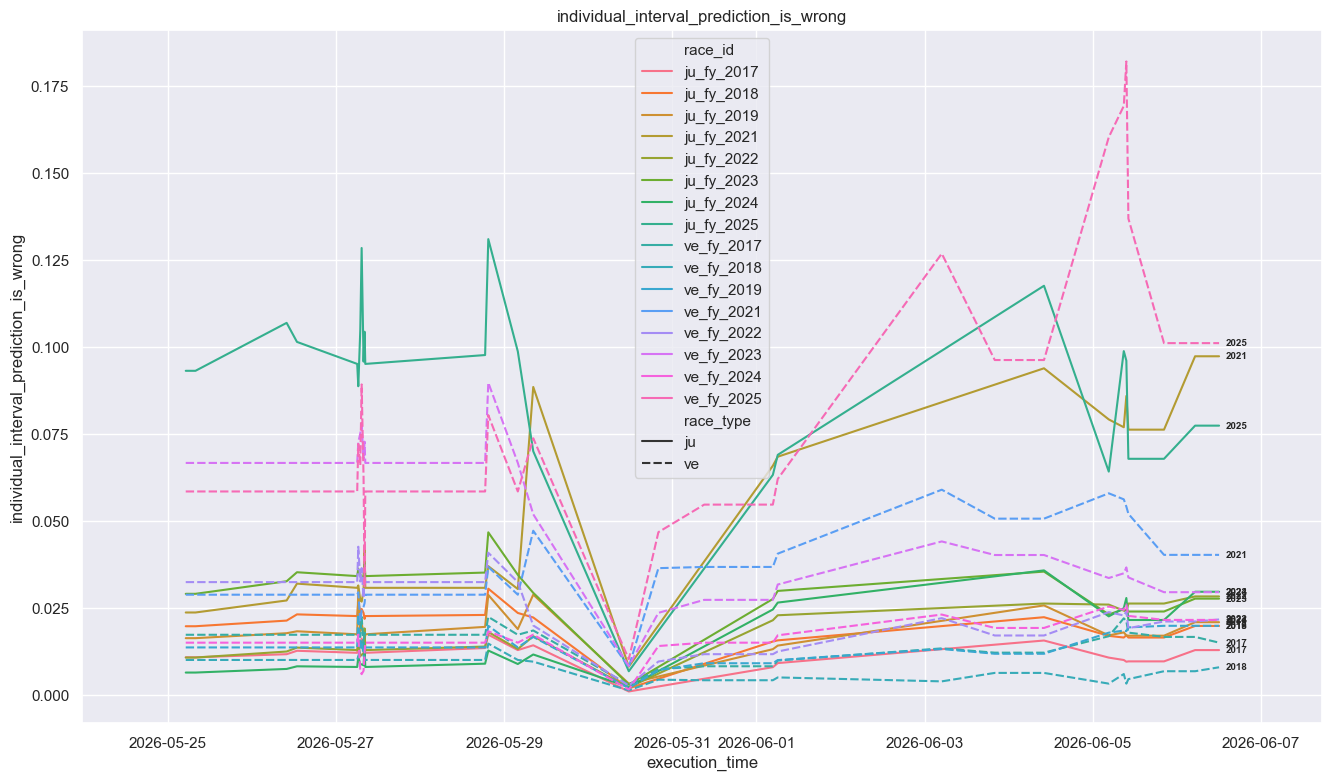

In [27]:
annotated_lineplot(
    last_executions_df,
    x='execution_time',
    y='individual_interval_prediction_is_wrong',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'average_size_of_an_individual_interval_minutes'}, xlabel='execution_time', ylabel='average_size_of_an_individual_interval_minutes'>

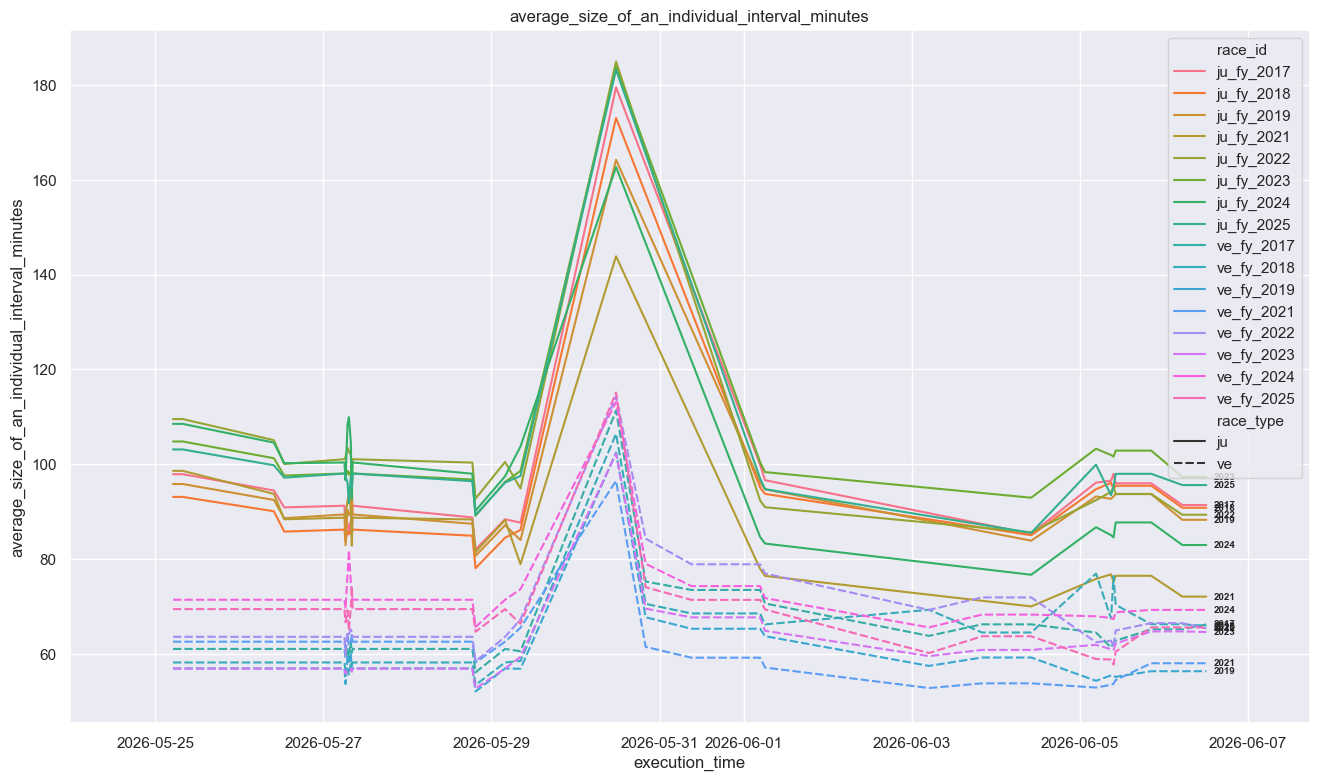

In [28]:
annotated_lineplot(
    last_executions_df,
    x='execution_time',
    y='average_size_of_an_individual_interval_minutes',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'relay_interval_prediction_wrong'}, xlabel='execution_time', ylabel='relay_interval_prediction_wrong'>

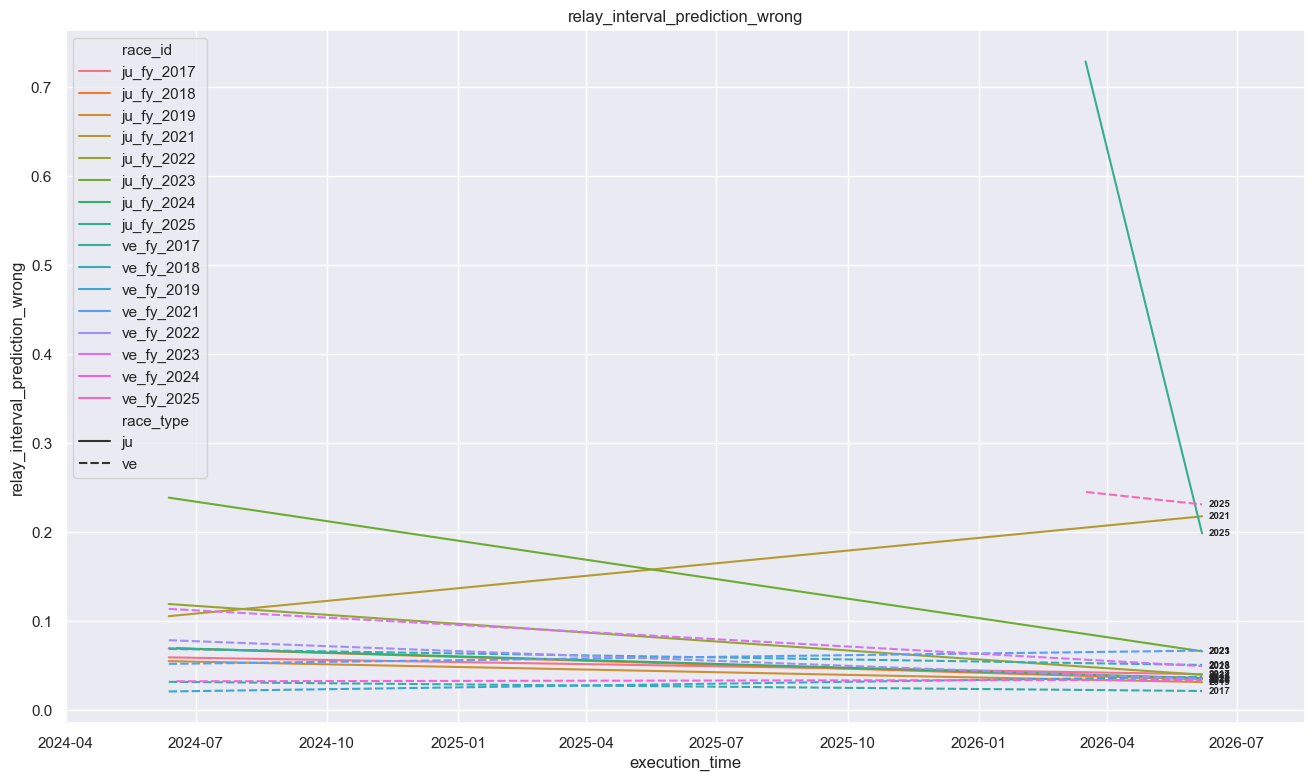

In [29]:
annotated_lineplot(
    first_last_df,
    x='execution_time',
    y='relay_interval_prediction_wrong',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

<Axes: title={'center': 'average_size_of_an_individual_interval_minutes'}, xlabel='execution_time', ylabel='average_size_of_an_individual_interval_minutes'>

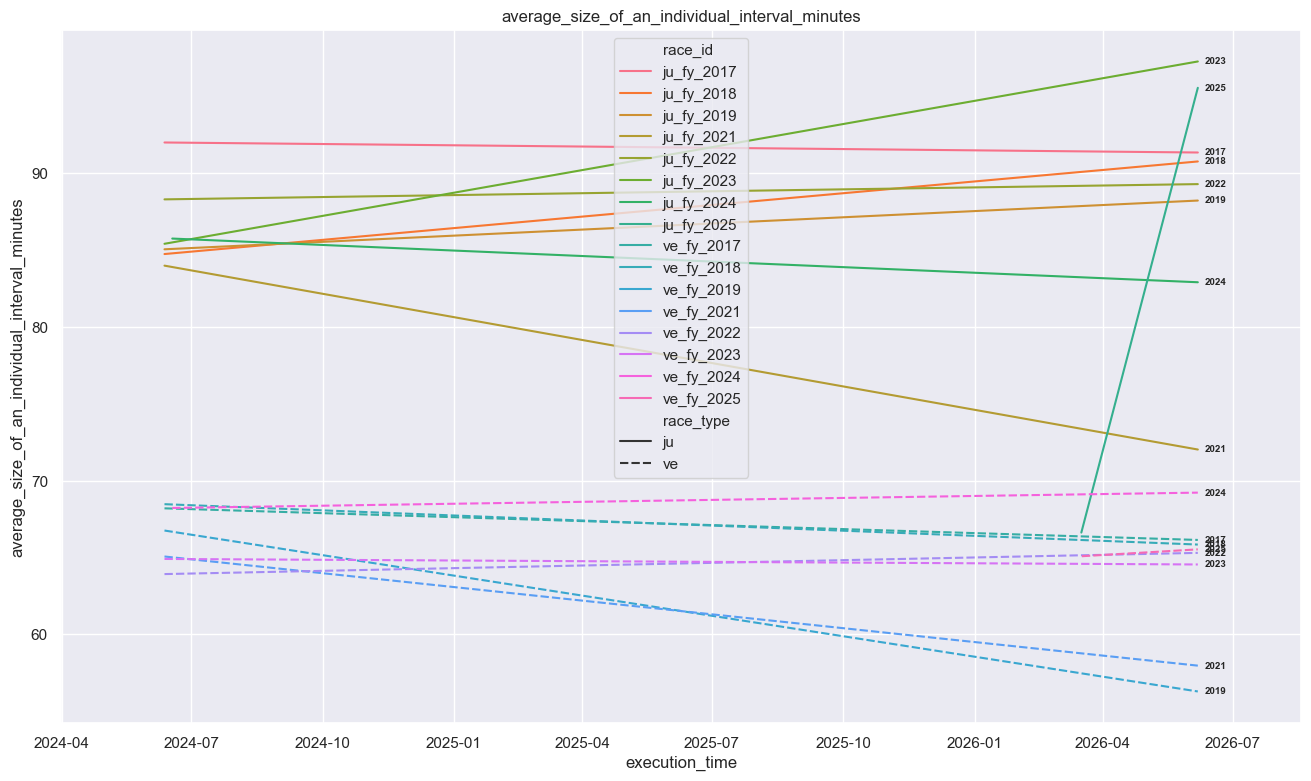

In [30]:
annotated_lineplot(
    first_last_df,
    x='execution_time',
    y='average_size_of_an_individual_interval_minutes',
    hue='race_id',
    style='race_type',
    annotation_col='race_year',
)

In [31]:
def _diff_from_first_to_last(col):
    result = clean_df.groupby('race_id').agg(
        first_time=(col, 'first'), 
        last_time=(col, 'last')).reset_index()
    
    result['diff'] = result['last_time'] - result['first_time']
    display(f'{col}: {result[['diff']].mean().item():.3f}')
    display(result[['race_id', 'diff']].sort_values('diff'))





In [32]:
_diff_from_first_to_last('average_error_of_individual_prediction_minutes')

'average_error_of_individual_prediction_minutes: -1.052'

,race_id,diff
7,ju_fy_2025,-4.562927
5,ju_fy_2023,-3.541574
13,ve_fy_2023,-3.440518
12,ve_fy_2022,-3.118744
4,ju_fy_2022,-2.458922
0,ju_fy_2017,-2.022461
2,ju_fy_2019,-1.587714
10,ve_fy_2019,-1.065439
1,ju_fy_2018,-0.967748
9,ve_fy_2018,-0.793527


In [33]:
_diff_from_first_to_last('individual_interval_prediction_is_wrong')
#sns.lineplot(data=clean_df, x='post_analysis_start_time', y='individual_interval_prediction_is_wrong', hue='race_id')

'individual_interval_prediction_is_wrong: -0.023'

,race_id,diff
7,ju_fy_2025,-0.233311
5,ju_fy_2023,-0.062760
12,ve_fy_2022,-0.029745
13,ve_fy_2023,-0.025967
4,ju_fy_2022,-0.024941
2,ju_fy_2019,-0.022646
1,ju_fy_2018,-0.020390
0,ju_fy_2017,-0.012194
9,ve_fy_2018,-0.009559
6,ju_fy_2024,-0.004156


In [34]:
_diff_from_first_to_last('relay_interval_prediction_wrong')

'relay_interval_prediction_wrong: -0.056'

,race_id,diff
7,ju_fy_2025,-0.530356
5,ju_fy_2023,-0.172730
4,ju_fy_2022,-0.079526
13,ve_fy_2023,-0.064325
12,ve_fy_2022,-0.043754
1,ju_fy_2018,-0.035093
6,ju_fy_2024,-0.033532
2,ju_fy_2019,-0.023517
0,ju_fy_2017,-0.018881
9,ve_fy_2018,-0.017984


In [35]:
_diff_from_first_to_last('average_size_of_an_individual_interval_minutes')

'average_size_of_an_individual_interval_minutes: 0.984'

,race_id,diff
3,ju_fy_2021,-11.967853
10,ve_fy_2019,-10.474239
11,ve_fy_2021,-7.103178
6,ju_fy_2024,-2.843675
9,ve_fy_2018,-2.627732
8,ve_fy_2017,-2.057694
0,ju_fy_2017,-0.651687
13,ve_fy_2023,-0.359519
15,ve_fy_2025,0.446337
4,ju_fy_2022,0.992587


In [36]:
# Select columns with numeric data types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    result = clean_df.groupby('race_id').agg(
    first_time=(col, 'first'), 
    last_time=(col, 'last')).reset_index()
    
    result['diff'] = result['last_time'] - result['first_time']
    display(f'{col}: {result[['diff']].mean().item():.3f}')


'num_estimates: 0.000'

'num_results: 0.000'

'num_runs_mean: 0.476'

'num_runs_median: 0.000'

'signed_average_error_of_individual_forecast_ie_runner_was_late_minutes: 0.858'

...

'runner_slower_than_post_interval_prediction: -0.047'

'average_individual_prediction_crps: 0.466'

'average_individual_prediction_nll: 0.052'

'average_relay_prediction_crps: 0.167'

'average_relay_prediction_nll: -0.097'

## 